# 01 · Exploratory data analysis

The question behind all of this: **what does a transaction's context tell us that the transaction
alone does not?**

The raw columns describe one payment in isolation. Real fraud detection works on history — how this
transaction compares to what the card normally does. This notebook checks which of those signals
actually exist in the data, including the ones that turn out not to.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from fraud_radar import data
from fraud_radar.features import build_features

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
ACCENT, DANGER = "#2F6F6B", "#A83B34"

df = build_features(data.load_all())
fraud, legit = df[df.is_fraud == 1], df[df.is_fraud == 0]
print(f"{len(df):,} transactions, {len(fraud):,} fraudulent ({df.is_fraud.mean():.3%})")

1,852,394 transactions, 9,651 fraudulent (0.521%)


## 1 · Amount

The single strongest raw signal. Fraud sits in a different part of the distribution entirely.

fraud   median  390.00   mean  530.66
legit   median   47.24   mean   67.65


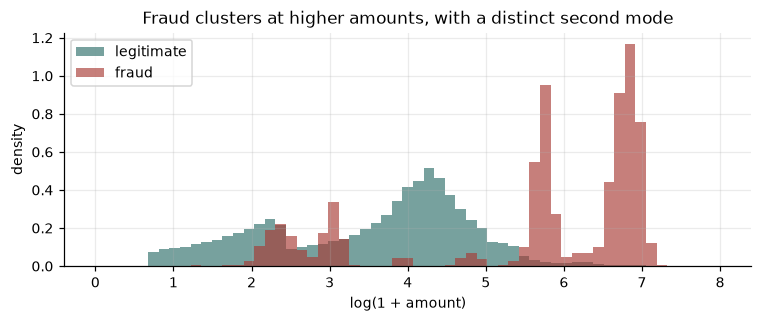

In [2]:
print(f"fraud   median {fraud.amt.median():7.2f}   mean {fraud.amt.mean():7.2f}")
print(f"legit   median {legit.amt.median():7.2f}   mean {legit.amt.mean():7.2f}")

fig, ax = plt.subplots(figsize=(7, 3))
bins = np.linspace(0, 8, 60)
ax.hist(np.log1p(legit.amt), bins=bins, density=True, alpha=.65, color=ACCENT, label="legitimate")
ax.hist(np.log1p(fraud.amt), bins=bins, density=True, alpha=.65, color=DANGER, label="fraud")
ax.set_xlabel("log(1 + amount)"); ax.set_ylabel("density")
ax.set_title("Fraud clusters at higher amounts, with a distinct second mode")
ax.legend(); plt.tight_layout(); plt.show()

Fraud has its own shape — a tight cluster of small test charges and a much larger mass around
several hundred dollars. Median fraud is **390** against **47** for legitimate transactions.

Worth naming honestly: this separation is cleaner than real card fraud, because the data is
simulated. Any performance measured here is optimistic.

## 2 · Time of day

Fraud is nocturnal, and dramatically so.

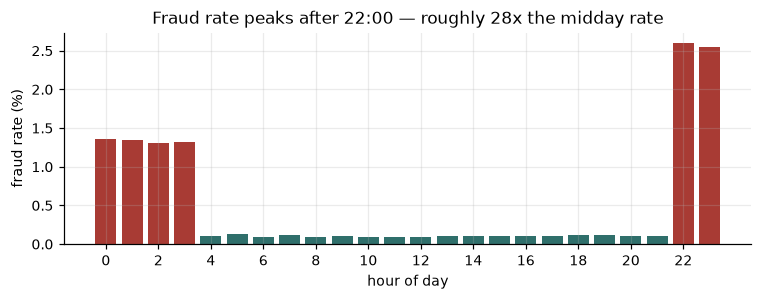

peak  22:00  2.60%
quiet 12:00  0.09%
ratio        29x


In [3]:
by_hour = df.groupby("hour").is_fraud.mean() * 100

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar(by_hour.index, by_hour.values, color=[DANGER if v > 1 else ACCENT for v in by_hour.values])
ax.set_xlabel("hour of day"); ax.set_ylabel("fraud rate (%)")
ax.set_title("Fraud rate peaks after 22:00 — roughly 28x the midday rate")
ax.set_xticks(range(0, 24, 2)); plt.tight_layout(); plt.show()

print(f"peak  22:00  {by_hour.loc[22]:.2f}%")
print(f"quiet 12:00  {by_hour.loc[12]:.2f}%")
print(f"ratio        {by_hour.loc[22] / by_hour.loc[12]:.0f}x")

## 3 · Merchant category

Ten-fold variation between the riskiest and safest categories. Online shopping leads; in-person
health and home purchases trail.

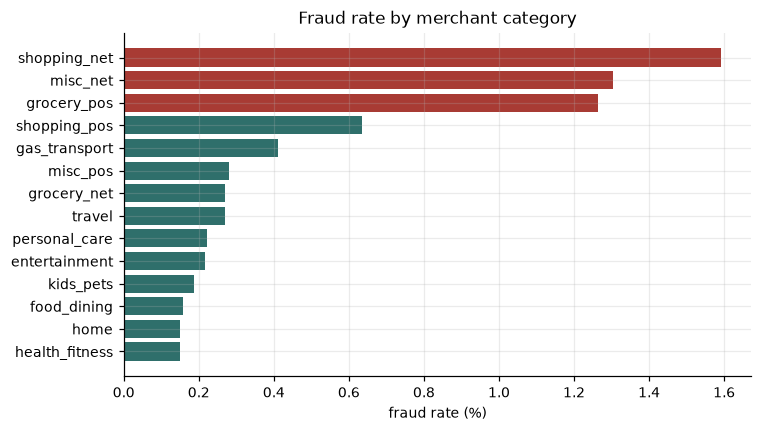

In [4]:
by_cat = (df.groupby("category").is_fraud.mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(by_cat.index, by_cat.values, color=[DANGER if v > 1 else ACCENT for v in by_cat.values])
ax.set_xlabel("fraud rate (%)"); ax.set_title("Fraud rate by merchant category")
plt.tight_layout(); plt.show()

## 4 · Do the history features work?

This is the real test of the feature engineering. For each engineered feature, compare its median
on fraud against its median on legitimate transactions. A feature that separates the classes is
worth keeping; one that doesn't is worth *saying so about*.

In [5]:
checks = ["amt_vs_card_mean", "implied_kmh", "txns_prev_24h", "txns_prev_1h",
          "amt_sum_prev_24h", "home_to_merchant_km", "km_from_prev_txn"]

rows = []
for c in checks:
    f, l = fraud[c].median(), legit[c].median()
    rows.append({"feature": c, "fraud": round(f, 2), "legitimate": round(l, 2),
                 "ratio": round(f / l, 2) if l not in (0, np.nan) and pd.notna(l) and l != 0 else np.nan})
pd.DataFrame(rows).set_index("feature")

,fraud,legitimate,ratio
feature,,,
amt_vs_card_mean,2.49,-0.19,-13.23
implied_kmh,64.28,21.05,3.05
txns_prev_24h,4.00,3.00,1.33
txns_prev_1h,0.00,0.00,NaN
amt_sum_prev_24h,1706.97,182.50,9.35
home_to_merchant_km,78.10,78.22,1.00
km_from_prev_txn,100.26,100.76,0.99


**Two features earn their place:**

- `amt_vs_card_mean` — this amount in standard deviations above what the card usually spends.
  Fraud sits **2.49σ** above its own card's baseline; legitimate transactions sit slightly *below*
  theirs. This is the feature that encodes "unusual **for this customer**", which no
  single-transaction column can express.
- `implied_kmh` — distance from the previous transaction divided by elapsed time. Fraud implies
  **64 km/h** of travel against 21 for legitimate use.

**Two features are dead, and that is a finding about the simulator:**

- `home_to_merchant_km`: 78.10 vs 78.22
- `km_from_prev_txn`: 100.26 vs 100.76

Sparkov scatters merchant locations around each customer at random, *regardless of whether the
transaction is fraudulent*. Geographic distance therefore carries no information here. In real card
data it is one of the strongest available signals — so this is a limitation of the simulation, not
evidence that geography doesn't matter. Keeping the features and reporting them as null results is
more honest than quietly deleting them.

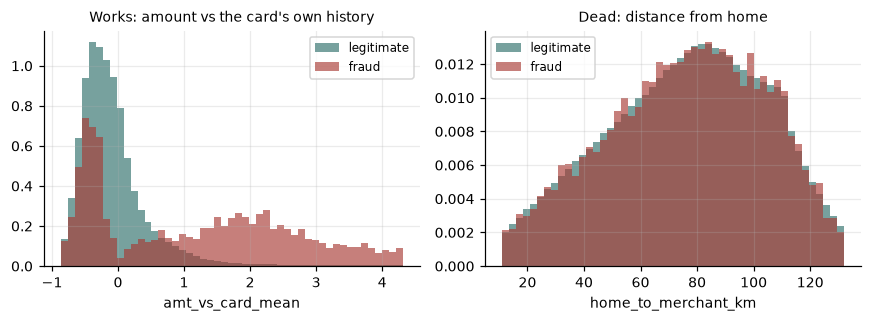

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, col, title in [(axes[0], "amt_vs_card_mean", "Works: amount vs the card's own history"),
                       (axes[1], "home_to_merchant_km", "Dead: distance from home")]:
    d = df[[col, "is_fraud"]].dropna()
    lo, hi = d[col].quantile([0.01, 0.99])
    bins = np.linspace(lo, hi, 50)
    ax.hist(d[d.is_fraud == 0][col], bins=bins, density=True, alpha=.65, color=ACCENT, label="legitimate")
    ax.hist(d[d.is_fraud == 1][col], bins=bins, density=True, alpha=.65, color=DANGER, label="fraud")
    ax.set_title(title, fontsize=9); ax.set_xlabel(col); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The left panel shows two clearly separated distributions. The right shows two curves sitting on
top of each other. That contrast is the whole argument for building history features.

## 5 · Drift across the two years

The fraud rate is not stable, which is what makes this dataset suitable for the drift work later.

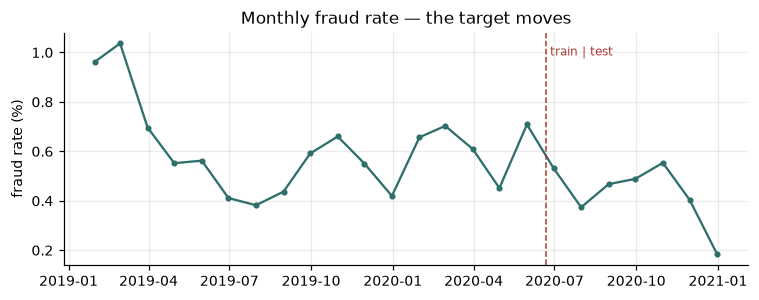

train period fraud rate  0.5789%
test  period fraud rate  0.3860%


In [7]:
monthly = df.set_index("ts").resample("ME").is_fraud.agg(["mean", "size"])
split_date = df[df.split == "test"].ts.min()

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(monthly.index, monthly["mean"] * 100, color=ACCENT, marker="o", ms=3)
ax.axvline(split_date, color=DANGER, ls="--", lw=1)
ax.text(split_date, ax.get_ylim()[1] * .95, " train | test", color=DANGER, fontsize=8, va="top")
ax.set_ylabel("fraud rate (%)"); ax.set_title("Monthly fraud rate — the target moves")
plt.tight_layout(); plt.show()

print(f"train period fraud rate  {df[df.split=='train'].is_fraud.mean():.4%}")
print(f"test  period fraud rate  {df[df.split=='test'].is_fraud.mean():.4%}")

---

## What this means for modeling

1. **Amount, hour and category** are strong single-transaction signals — a supervised model will
   find them easily.
2. **`amt_vs_card_mean` and `implied_kmh`** add genuine per-card context that no single row contains.
3. **Geographic distance is inert** in this simulation. Reported, not hidden.
4. **The target drifts**, so the chronological split is doing real work — a random split would
   quietly flatter every model.

Next: `02-model-comparison.ipynb`.